<a href="https://colab.research.google.com/github/jacobdawson093-tech/Montgomery-County-and-Bias-Incidents-Analysis/blob/main/models/Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ingestion

In [18]:
import requests
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency, fisher_exact, pearsonr, f_oneway
import numpy as np
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import datetime
import os
os.makedirs("graphs", exist_ok=True)

url = "https://api.census.gov/data/2024/acs/acs5"
response = requests.get(url)
data = response.json()
url2 = "https://data.montgomerycountymd.gov/api/v3/views/7bhj-887p/query.json?app_token=8kUbrmGzgoxqe4z7C91iV3wmC"
response2 = requests.get(url2)
data2 = response2.json()

df1 = pd.DataFrame(data)

df2 = pd.DataFrame(data2)

In [19]:
# Convert 'incident_date' to datetime
df2['incident_date'] = pd.to_datetime(df2['incident_date'])

# Create a binary 'resolved' column from 'status'
df2['resolved'] = df2['status'].apply(lambda x: 1 if x in ['Closed-Admin', 'Closed-Investigation', 'Closed-Exception', 'Closed-Arrest'] else 0)

# Convert suspect age columns to numeric, coercing errors to NaN
df2['suspects_less_than_18_years'] = pd.to_numeric(df2['suspects_less_than_18_years'], errors='coerce').fillna(0).astype(int)
df2['suspects_18_35_years_old'] = pd.to_numeric(df2['suspects_18_35_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_36_45_years_old'] = pd.to_numeric(df2['suspects_36_45_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_46_55_years_old'] = pd.to_numeric(df2['suspects_46_55_years_old'], errors='coerce').fillna(0).astype(int)
df2['suspects_55_years_old'] = pd.to_numeric(df2['suspects_55_years_old'], errors='coerce').fillna(0).astype(int)

# Create a binary variable for incidents with suspects under 18
df2['under_18_suspect'] = df2['suspects_less_than_18_years'].apply(lambda x: 1 if x > 0 else 0)

#Create bias category to seperate religious bias to racial/ethnic biases
def categorize_bias(bias_code):
    religious_biases = ['Anti-Jewish', 'Anti-Muslim', 'Anti-Catholic', 'Anti-Sikh', 'Anti-Hindhu', 'Anti-Protestant', 'Anti-Buddhist']
    racial_ethnic_biases = ['Anti-Black', 'Anti-White', 'Anti-Asian', 'Anti-Hispanic', 'Anti-Multi-Racial', 'Anti-American Indian', 'Anti-Other Race/Ethnicity']

    if bias_code in religious_biases:
        return 'Religious Bias'
    elif bias_code in racial_ethnic_biases:
        return 'Racial/Ethnic Bias'
    else:
        return 'Other Bias' # For categories not explicitly religious or racial/ethnic

df2['bias_category'] = df2['bias_code'].apply(categorize_bias)

In [20]:
# 1. Map Police Districts to Cities
# Based on the provided police district information:
district_to_city_map = {
    '1D': 'Rockville',
    '2D': 'Bethesda',
    '3D': 'Silver Spring',
    '4D': 'Wheaton',
    '5D': 'Germantown',
    '6D': 'Gaithersburg' # Montgomery Village is within Gaithersburg for census purposes
}

df2['city'] = df2['district'].map(district_to_city_map)

print("District to City Mapping created and applied to df2:")
display(df2[['district', 'city']].head())

# 2. Fetch ACS Data for Montgomery County Places (Cities) using requests for multiple years

# Define the ACS variables we want to fetch
acs_variables = {
    'B01003_001E': 'Total Population',
    'B02001_002E': 'White Alone',
    'B02001_003E': 'Black or African American Alone',
    'B02001_004E': 'American Indian and Alaska Native Alone',
    'B02001_005E': 'Asian Alone',
    'B02001_006E': 'Native Hawaiian and Other Pacific Islander Alone',
    'B02001_007E': 'Some Other Race Alone',
    'B03003_003E': 'Hispanic or Latino',
    'B19013_001E': 'Median Household Income',
    'B17001_002E': 'Poverty Status (Below Poverty Level)'
}

variables_str = ','.join(acs_variables.keys())

all_acs_dfs = []
# Loop through years from 2016 up to the current year (to capture the latest available ACS 5-year estimates)
# ACS 5-year estimates for year Y are typically released in December of year Y+1. So, requesting up to the current year
# will ensure we get the latest published data without trying to fetch future, unavailable data.
for current_year in range(2016, datetime.datetime.now().year):
    acs_api_url = f"https://api.census.gov/data/{current_year}/acs/acs5?get=NAME,{variables_str}&for=place:*&in=state:24"
    print(f"Fetching data from: {acs_api_url}")

    try:
        response = requests.get(acs_api_url)
        response.raise_for_status() # Raise HTTPError for bad responses (4xx or 5xx)
        data = response.json()

        # The first row contains headers, subsequent rows are data
        headers = data[0]
        temp_acs_df = pd.DataFrame(data[1:], columns=headers)

        # Rename columns for clarity
        temp_acs_df = temp_acs_df.rename(columns=acs_variables)

        # Extract city name from the 'NAME' column
        temp_acs_df['city'] = temp_acs_df['NAME'].apply(lambda x: x.split(',')[0].replace(' city', '').replace(' CDP', '').strip())

        # Convert demographic columns to numeric, handling potential non-numeric values
        for col in acs_variables.values():
            temp_acs_df[col] = pd.to_numeric(temp_acs_df[col], errors='coerce')

        # Add a year column to identify the ACS 5-year estimate
        temp_acs_df['acs_year_end'] = current_year
        all_acs_dfs.append(temp_acs_df)

    except requests.exceptions.RequestException as e:
        print(f"Error fetching data for {current_year}: {e}")
        # Print response content if available for more debugging info
        if response is not None:
            print(f"Response content: {response.text}")
        continue # Skip to the next year
    except json.JSONDecodeError as e:
        print(f"JSONDecodeError for {current_year}: {e}")
        # Print response content if available for more debugging info
        if response is not None:
            print(f"Response content: {response.text}")
        continue # Skip to the next year

# Concatenate all ACS dataframes
acs_df = pd.concat(all_acs_dfs, ignore_index=True)

# 3. Merge ACS Data with df2

# Standardize city names in ACS data to match our district map
acs_df['city_standardized'] = acs_df['city'].str.replace(' city', '').str.replace(' CDP', '').str.strip()

# Filter df2 for incidents that have a mapped city and are within the ACS data range (up to current year)
df2_filtered = df2.dropna(subset=['city']).copy()
df2_filtered = df2_filtered[df2_filtered['incident_date'].dt.year < datetime.datetime.now().year]

# Extract the year from the incident date for merging
df2_filtered['incident_year'] = df2_filtered['incident_date'].dt.year

# Merge df2_filtered with acs_df
# Use a left merge to keep all filtered bias incidents and add ACS data where available
df2_merged = pd.merge(df2_filtered, acs_df,
                      left_on=['city', 'incident_year'],
                      right_on=['city_standardized', 'acs_year_end'],
                      how='left')

print("\nMerged DataFrame (df2_merged) head:")
display(df2_merged.head())

print("\nInfo on merged DataFrame:")
df2_merged.info()

# Display fetched ACS data head
print("\nFetched and Combined ACS Data for Montgomery County Cities (multiple years):")
display(acs_df.head())
print("\nInfo on Combined ACS DataFrame:")
acs_df.info()

District to City Mapping created and applied to df2:


,district,city
0,5D,Germantown
1,3D,Silver Spring
2,2D,Bethesda
3,4D,Wheaton
4,6D,Gaithersburg


Fetching data from: https://api.census.gov/data/2016/acs/acs5?get=NAME,B01003_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B03003_003E,B19013_001E,B17001_002E&for=place:*&in=state:24
Fetching data from: https://api.census.gov/data/2017/acs/acs5?get=NAME,B01003_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B03003_003E,B19013_001E,B17001_002E&for=place:*&in=state:24
Fetching data from: https://api.census.gov/data/2018/acs/acs5?get=NAME,B01003_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B03003_003E,B19013_001E,B17001_002E&for=place:*&in=state:24
Fetching data from: https://api.census.gov/data/2019/acs/acs5?get=NAME,B01003_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_006E,B02001_007E,B03003_003E,B19013_001E,B17001_002E&for=place:*&in=state:24
Fetching data from: https://api.census.gov/data/2020/acs/acs5?get=NAME,B01003_001E,B02001_002E,B02001_003E,B02001_004E,B02001_005E,B02001_00

,:id,:version,:created_at,:updated_at,id,incident_date,district,bias_code,bias,status,...,Native Hawaiian and Other Pacific Islander Alone,Some Other Race Alone,Hispanic or Latino,Median Household Income,Poverty Status (Below Poverty Level),state,place,city_y,acs_year_end,city_standardized
0,row-xevh~83re_767e,rv-4g7b.bahn.2x49,2026-01-09T08:11:03.571Z,2026-01-09T08:11:03.571Z,250058134,2025-12-30,2D,Anti-Arab,Other,Closed-Arrest,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,row-4uuy-9d8j~2tb4,rv-j5vs_uwj5-tem3,2026-01-09T08:11:03.571Z,2026-01-09T08:11:03.571Z,250058029,2025-12-29,2D,Anti-Jewish,Vandalism,Open,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,row-ebs8~v7su~29nq,rv-yse9-tdyn.ehh8,2026-01-09T08:11:03.571Z,2026-01-09T08:11:03.571Z,250057923,2025-12-28,2D,Anti-Hispanic,Assault (simple),Open,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,row-iq9a-uc7a~xye6,rv-gj2q~8gqc.8aag,2026-01-09T08:11:03.571Z,2026-01-09T08:11:03.571Z,250057472,2025-12-24,2D,Anti-Jewish,Other,Open,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,row-9j8p_tfj2.7s3t,rv-5mmv.t6g2-gwxe,2026-01-09T08:11:03.571Z,2026-01-09T08:11:03.571Z,250057463,2025-12-24,2D,Anti-Black,Assault (simple),Open,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Info on merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891 entries, 0 to 1890
Data columns (total 41 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   :id                                               1891 non-null   object        
 1   :version                                          1891 non-null   object        
 2   :created_at                                       1891 non-null   object        
 3   :updated_at                                       1891 non-null   object        
 4   id                                                1891 non-null   object        
 5   incident_date                                     1891 non-null   datetime64[ns]
 6   district                                          1891 non-null   object        
 7   bias_code                                         1887 non-null   object        
 8   b

,NAME,Total Population,White Alone,Black or African American Alone,American Indian and Alaska Native Alone,Asian Alone,Native Hawaiian and Other Pacific Islander Alone,Some Other Race Alone,Hispanic or Latino,Median Household Income,Poverty Status (Below Poverty Level),state,place,city,acs_year_end,city_standardized
0,"Annapolis Neck CDP, Maryland",10649,9055,903,0,212,0,45,652,125741,229,24,01635,Annapolis Neck,2016,Annapolis Neck
1,"Allen CDP, Maryland",84,44,40,0,0,0,0,0,-666666666,44,24,00800,Allen,2016,Allen
2,"Antietam CDP, Maryland",137,101,36,0,0,0,0,0,111905,15,24,01750,Antietam,2016,Antietam
3,"Aquasco CDP, Maryland",855,346,432,13,0,0,0,0,63571,14,24,01925,Aquasco,2016,Aquasco
4,"Baden CDP, Maryland",1906,990,703,0,10,0,153,215,90644,59,24,03500,Baden,2016,Baden



Info on Combined ACS DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4752 entries, 0 to 4751
Data columns (total 16 columns):
 #   Column                                            Non-Null Count  Dtype 
---  ------                                            --------------  ----- 
 0   NAME                                              4752 non-null   object
 1   Total Population                                  4752 non-null   int64 
 2   White Alone                                       4752 non-null   int64 
 3   Black or African American Alone                   4752 non-null   int64 
 4   American Indian and Alaska Native Alone           4752 non-null   int64 
 5   Asian Alone                                       4752 non-null   int64 
 6   Native Hawaiian and Other Pacific Islander Alone  4752 non-null   int64 
 7   Some Other Race Alone                             4752 non-null   int64 
 8   Hispanic or Latino                                4752 non-null   int64 
 9

# Random Forest Regression, Logistic Regression, and Decision Tree

In [21]:
print("\n--- Model 1: Bias Incident Count Prediction (Random Forest Regressor) ---")

# 1. Aggregate Data for Count Prediction
# Group by city and incident year to get total incidents and relevant demographic data
df_incidents_per_city_year = df2_merged.groupby(['city_x', 'incident_year']).size().reset_index(name='incident_count')

# Extract unique demographic data per city-year combination from df2_merged
demographic_features_for_counts = [
    'city_x', 'incident_year',
    'Total Population', 'Median Household Income',
    'White Alone', 'Black or African American Alone',
    'American Indian and Alaska Native Alone', 'Asian Alone',
    'Native Hawaiian and Other Pacific Islander Alone', 'Some Other Race Alone',
    'Hispanic or Latino', 'Poverty Status (Below Poverty Level)'
]
unique_demographics = df2_merged[demographic_features_for_counts].drop_duplicates(subset=['city_x', 'incident_year'])

# Merge incident counts with demographic data
model1_df = pd.merge(df_incidents_per_city_year, unique_demographics,
                     on=['city_x', 'incident_year'],
                     how='left')

# Drop rows where demographic data might be missing
model1_df.dropna(subset=['Total Population', 'Median Household Income'], inplace=True)

# 2. Define Features (X) and Target (y) for Count Prediction
features_count = [
    'Total Population',
    'Median Household Income',
    'White Alone',
    'Black or African American Alone',
    'American Indian and Alaska Native Alone',
    'Asian Alone',
    'Native Hawaiian and Other Pacific Islander Alone',
    'Some Other Race Alone',
    'Hispanic or Latino',
    'Poverty Status (Below Poverty Level)',
    'incident_year' # Include year as a feature
]
X_count = model1_df[features_count]
y_count = model1_df['incident_count']

# 3. Split Data
X_train_count, X_test_count, y_train_count, y_test_count = train_test_split(X_count, y_count, test_size=0.2, random_state=42)

# 4. Train and Evaluate Random Forest Regressor
model_rfr = RandomForestRegressor(n_estimators=100, random_state=42)
model_rfr.fit(X_train_count, y_train_count)
y_pred_count = model_rfr.predict(X_test_count)

mse_rfr = mean_squared_error(y_test_count, y_pred_count)
r2_rfr = r2_score(y_test_count, y_pred_count)

print(f"Mean Squared Error: {mse_rfr:.2f}")
print(f"R-squared: {r2_rfr:.2f}")

print("\n--- Model 2: Case Resolution Prediction (Decision Tree & Logistic Regression) ---")

# 1. Prepare Data for Resolution Prediction
df2_ml_res = df2_merged.copy()

# Drop rows where essential demographic data (features) might be missing
df2_ml_res.dropna(subset=[
    'Total Population', 'Median Household Income',
    'White Alone', 'Black or African American Alone',
    'American Indian and Alaska Native Alone', 'Asian Alone',
    'Hispanic or Latino', 'Poverty Status (Below Poverty Level)'
], inplace=True)

# 2. Define Features (X) and Target (y) for Resolution Prediction
features_resolve = [
    'bias_code',
    'bias_category',
    'victim_type',
    'under_18_suspect', # Binary flag (0 or 1)
    'Total Population',
    'Median Household Income',
    'White Alone',
    'Black or African American Alone',
    'American Indian and Alaska Native Alone',
    'Asian Alone',
    'Hispanic or Latino',
    'Poverty Status (Below Poverty Level)'
]

categorical_features_resolve = ['bias_code', 'bias_category', 'victim_type']
numerical_features_resolve = [
    'under_18_suspect',
    'Total Population',
    'Median Household Income',
    'White Alone',
    'Black or African American Alone',
    'American Indian and Alaska Native Alone',
    'Asian Alone',
    'Hispanic or Latino',
    'Poverty Status (Below Poverty Level)'
]

X_resolve = df2_ml_res[features_resolve]
y_resolve = df2_ml_res['resolved']

# 3. Split Data
X_train_resolve, X_test_resolve, y_train_resolve, y_test_resolve = train_test_split(X_resolve, y_resolve, test_size=0.2, random_state=42)

# 4. Preprocessing Pipeline
# Apply OneHotEncoder to categorical features and StandardScaler to numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_resolve),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_resolve)
    ])

# 5a. Train and Evaluate Decision Tree Classifier
print("\n--- Model 2a: Case Resolution Prediction (Decision Tree Classifier) ---")
pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', DecisionTreeClassifier(random_state=42))])
pipeline_dt.fit(X_train_resolve, y_train_resolve)
y_pred_dt = pipeline_dt.predict(X_test_resolve)
y_proba_dt = pipeline_dt.predict_proba(X_test_resolve)[:, 1] # Probability of the positive class

accuracy_dt = accuracy_score(y_test_resolve, y_pred_dt)
report_dt = classification_report(y_test_resolve, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_resolve, y_proba_dt)

print(f"Accuracy: {accuracy_dt:.2f}")
print("Classification Report:\n", report_dt)
print(f"ROC AUC Score: {roc_auc_dt:.2f}")

# 5b. Train and Evaluate Logistic Regression
print("\n--- Model 2b: Case Resolution Prediction (Logistic Regression) ---")
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(solver='liblinear', random_state=42))])
pipeline_lr.fit(X_train_resolve, y_train_resolve)
y_pred_lr = pipeline_lr.predict(X_test_resolve)
y_proba_lr = pipeline_lr.predict_proba(X_test_resolve)[:, 1] # Probability of the positive class

accuracy_lr = accuracy_score(y_test_resolve, y_pred_lr)
report_lr = classification_report(y_test_resolve, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test_resolve, y_proba_lr)

print(f"Accuracy: {accuracy_lr:.2f}")
print("Classification Report:\n", report_lr)
print(f"ROC AUC Score: {roc_auc_lr:.2f}")


--- Model 1: Bias Incident Count Prediction (Random Forest Regressor) ---
Mean Squared Error: 160.57
R-squared: 0.72

--- Model 2: Case Resolution Prediction (Decision Tree & Logistic Regression) ---

--- Model 2a: Case Resolution Prediction (Decision Tree Classifier) ---
Accuracy: 0.72
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.84      0.79       192
           1       0.68      0.54      0.60       123

    accuracy                           0.72       315
   macro avg       0.71      0.69      0.69       315
weighted avg       0.72      0.72      0.71       315

ROC AUC Score: 0.70

--- Model 2b: Case Resolution Prediction (Logistic Regression) ---
Accuracy: 0.73
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.88      0.80       192
           1       0.72      0.51      0.60       123

    accuracy                           0.73       315
   macro avg   

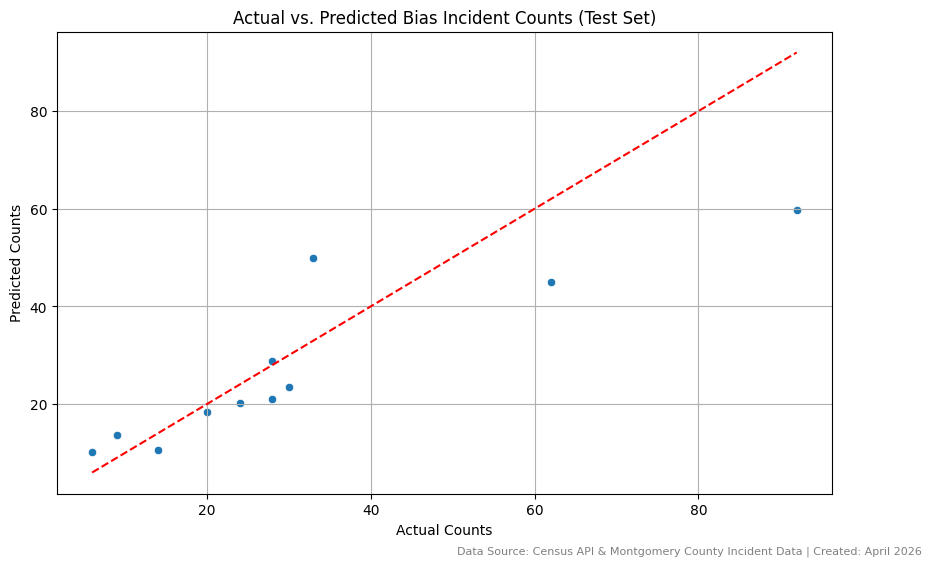

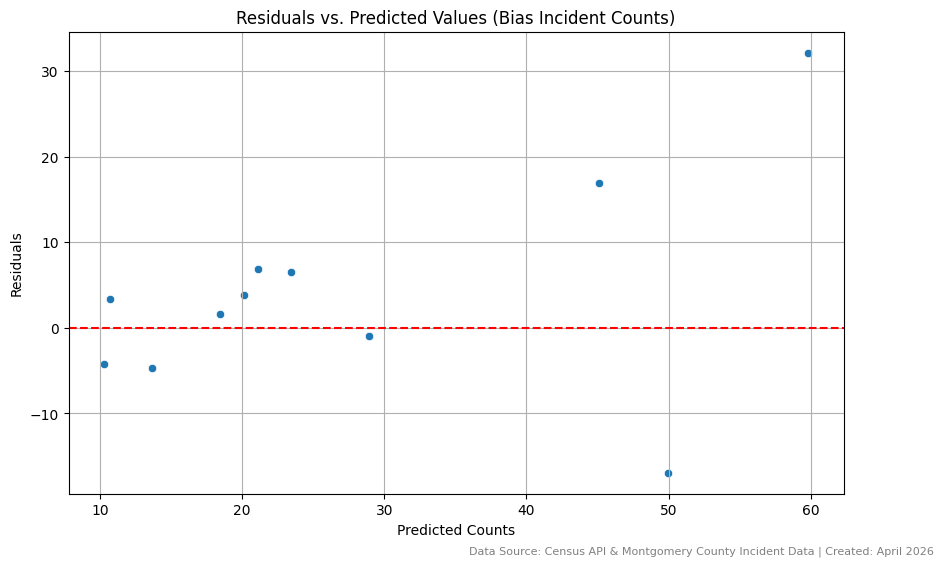

<Figure size 800x600 with 0 Axes>

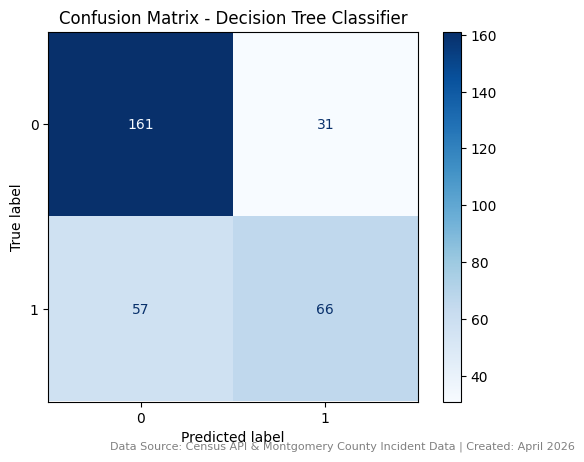

<Figure size 800x600 with 0 Axes>

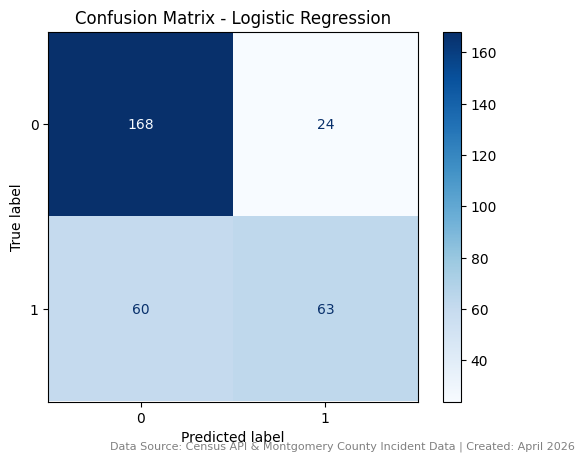

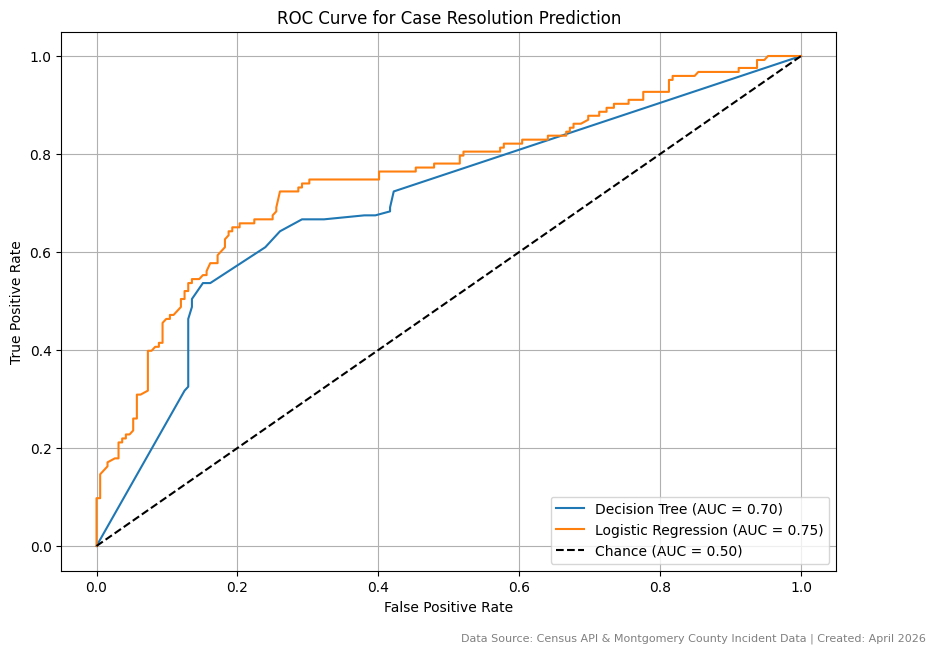

In [22]:
# 1. Actual vs. Predicted Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_count, y=y_pred_count)
plt.plot([y_test_count.min(), y_test_count.max()], [y_test_count.min(), y_test_count.max()], 'r--') # Ideal line
plt.title('Actual vs. Predicted Bias Incident Counts (Test Set)')
plt.xlabel('Actual Counts')
plt.ylabel('Predicted Counts')
plt.grid(True)
plt.figtext(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray')
plt.show()

# 2. Residual Plot
residuals = y_test_count - y_pred_count
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_count, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Bias Incident Counts)')
plt.xlabel('Predicted Counts')
plt.ylabel('Residuals')
plt.grid(True)
plt.figtext(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray')
plt.show()

# 1. Confusion Matrix for Decision Tree Classifier
cm_dt = confusion_matrix(y_test_resolve, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=pipeline_dt.named_steps['classifier'].classes_)
plt.figure(figsize=(8, 6))
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.figtext(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray')
plt.show()

# 2. Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test_resolve, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=pipeline_lr.named_steps['classifier'].classes_)
plt.figure(figsize=(8, 6))
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.figtext(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray')
plt.show()

# 3. ROC Curve for both Classifiers
plt.figure(figsize=(10, 7))

# Decision Tree ROC Curve
fpr_dt, tpr_dt, _ = roc_curve(y_test_resolve, y_proba_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# Logistic Regression ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test_resolve, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)') # Random classifier
plt.title('ROC Curve for Case Resolution Prediction')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.figtext(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray')
plt.show()

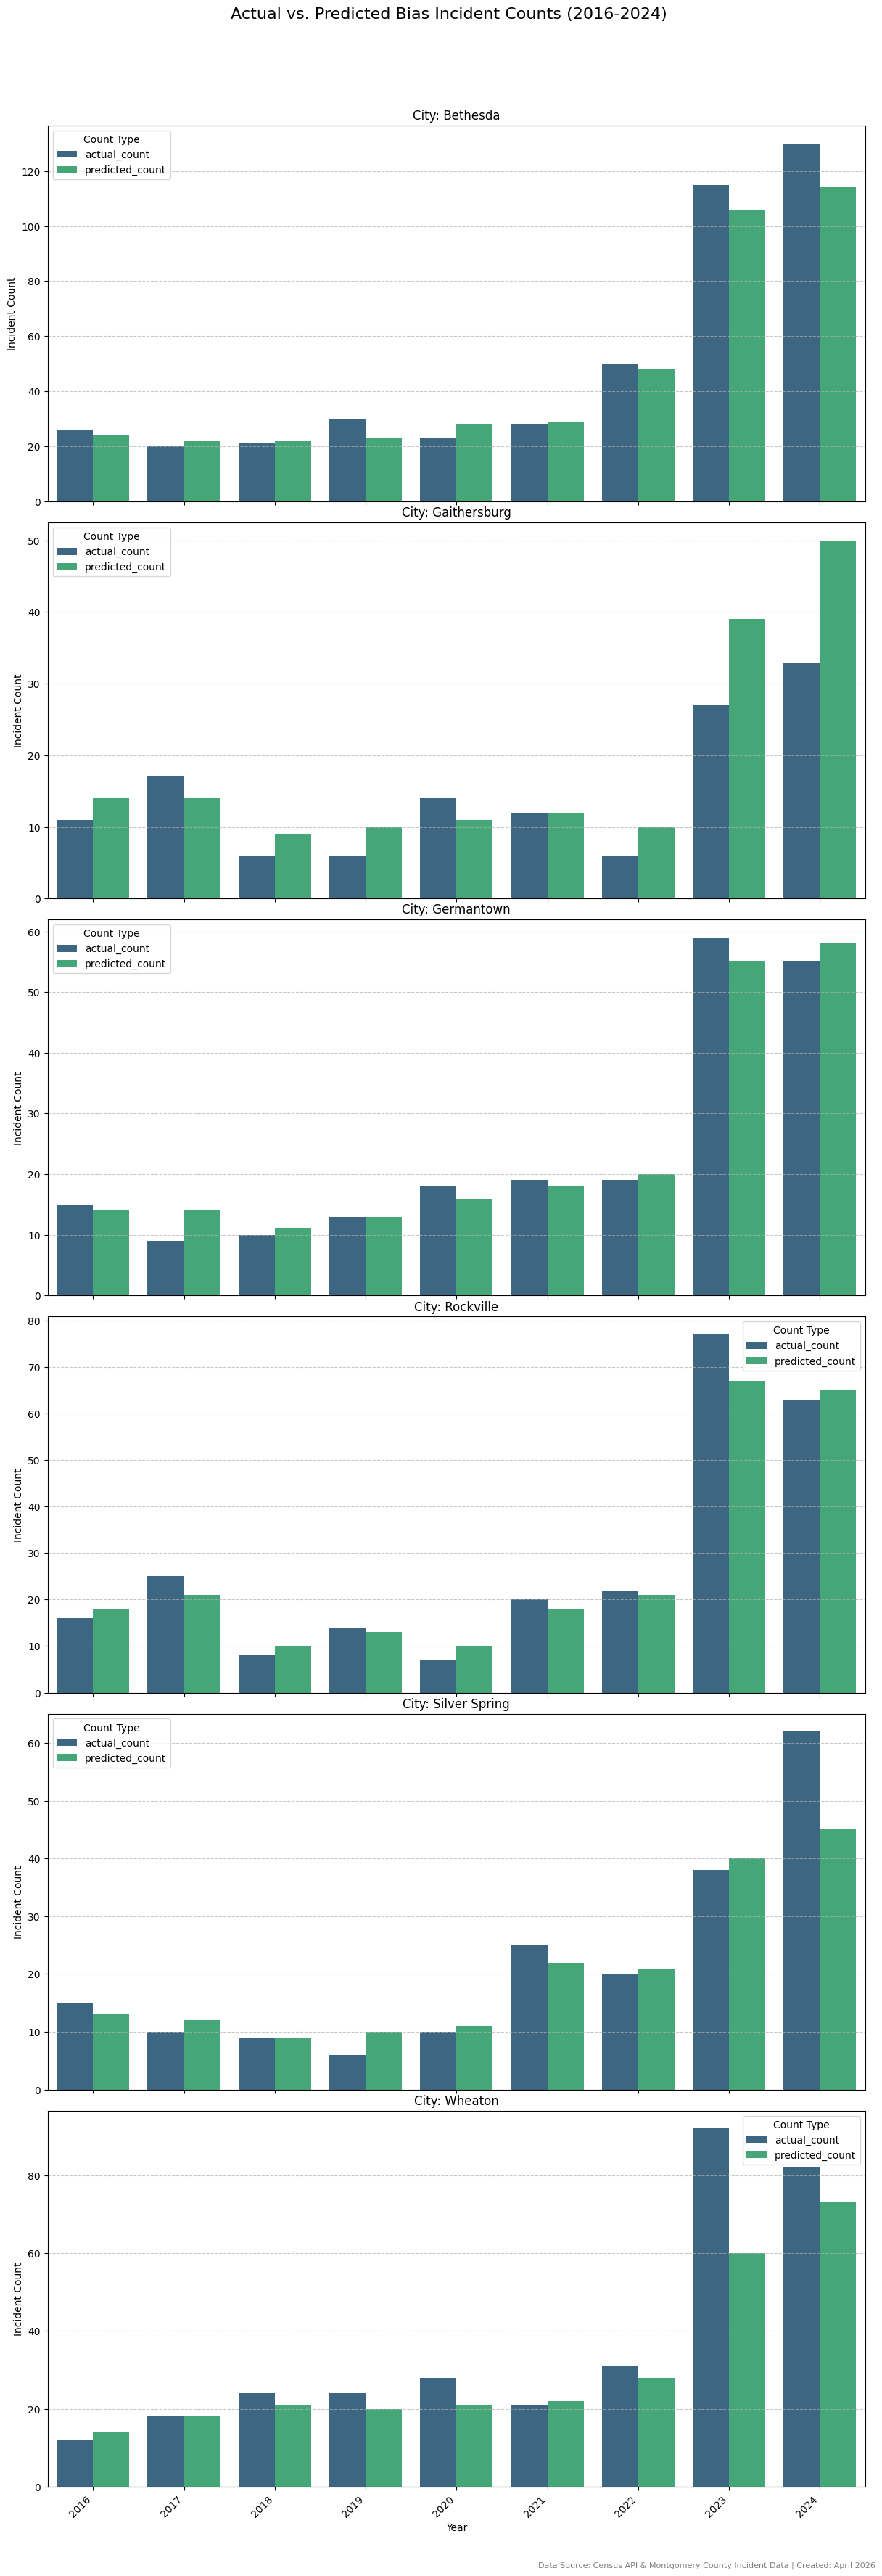

In [23]:
# X_count and y_count already represent all city-year combinations from 2016-2024 from model1_df
y_pred_all_years = model_rfr.predict(X_count)


comparison_df = model1_df[['city_x', 'incident_year']].copy()
comparison_df['actual_count'] = y_count
comparison_df['predicted_count'] = y_pred_all_years.round(0).astype(int) # Round to whole numbers


plot_df = comparison_df.melt(id_vars=['city_x', 'incident_year'],
                             value_vars=['actual_count', 'predicted_count'],
                             var_name='Type', value_name='Count')


# Get unique cities to iterate for subplots
ordered_cities = sorted(plot_df['city_x'].unique())

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=len(ordered_cities), ncols=1, figsize=(12, 6 * len(ordered_cities)), sharex=True)
fig.suptitle('Actual vs. Predicted Bias Incident Counts (2016-2024)', y=0.99, fontsize=16)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.96])

for i, city in enumerate(ordered_cities):
    city_data = plot_df[plot_df['city_x'] == city]
    sns.barplot(x='incident_year', y='Count', hue='Type', data=city_data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'City: {city}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Incident Count')
    axes[i].legend(title='Count Type')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

# Add global figtext for the entire figure, which might be positioned better or you can add to each subplot as above.
fig.text(0.99, 0.01, 'Data Source: Census API & Montgomery County Incident Data | Created: April 2026', horizontalalignment='right', fontsize=8, color='gray', transform=fig.transFigure)

plt.xticks(rotation=45, ha='right')
plt.show()